In [119]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [120]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Ti


In [121]:
import os
from PIL import Image

In [122]:
augment = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    )
])

In [123]:
# input_dir = "../data2/train"
# output_dir = "../data2/train_aug"

# os.makedirs(output_dir, exist_ok=True)

In [124]:
# num_augmented_per_image = 6  # you can change this

# for class_name in os.listdir(input_dir):
#     class_path = os.path.join(input_dir, class_name)

#     save_class_path = os.path.join(output_dir, class_name)
#     os.makedirs(save_class_path, exist_ok=True)

#     for img_name in os.listdir(class_path):
#         img_path = os.path.join(class_path, img_name)

#         try:
#             img = Image.open(img_path).convert("RGB")

#             for i in range(num_augmented_per_image):
#                 augmented_img = augment(img)

#                 save_name = f"{img_name.split('.')[0]}_aug{i}.jpg"
#                 augmented_img.save(os.path.join(save_class_path, save_name))

#         except:
#             pass

In [125]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
])

In [126]:
train_dataset = datasets.ImageFolder(
    "../data2/train_aug",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    "../data2/val",
    transform=transform
)

In [127]:
print(train_dataset.classes)

['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']


In [128]:
# import matplotlib.pyplot as plt
# import torchvision

# grid = torchvision.utils.make_grid(images[:100])
# plt.imshow(grid.permute(1, 2, 0))
# plt.axis("off")
# plt.show()

In [129]:
from collections import Counter

print(Counter(train_dataset.targets))
print(Counter(val_dataset.targets))

Counter({1: 3588, 4: 2928, 0: 2730, 6: 2550, 5: 1662, 2: 960, 3: 324})
Counter({1: 150, 4: 123, 0: 114, 6: 107, 5: 70, 2: 41, 3: 14})


In [130]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [131]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [132]:
model = models.densenet121(pretrained=True)

c:\Users\desig\Desktop\Summer research\CV\Potatoplant\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\desig\Desktop\Summer research\CV\Potatoplant\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [133]:
model.classifier = nn.Linear(
    model.classifier.in_features,
    7
)

In [134]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [135]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [136]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=1e-4
)

In [137]:
model.train()

running_loss = 0.0

for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

print("Training completed!")
print("Loss:", running_loss)

Training completed!
Loss: 736.059023141861


In [138]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 55.57%


In [139]:
num_epochs = 30

In [140]:
train_losses = []
val_accuracies = []

In [141]:
for epoch in range(num_epochs):

    # TRAINING
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    val_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")

Epoch 1/30
Loss: 1.2446
Validation Accuracy: 61.87%
Epoch 2/30
Loss: 1.0809
Validation Accuracy: 64.46%
Epoch 3/30
Loss: 0.9857
Validation Accuracy: 65.75%
Epoch 4/30
Loss: 0.9187
Validation Accuracy: 66.07%
Epoch 5/30
Loss: 0.8706
Validation Accuracy: 69.14%
Epoch 6/30
Loss: 0.8369
Validation Accuracy: 68.82%
Epoch 7/30
Loss: 0.8091
Validation Accuracy: 68.98%
Epoch 8/30
Loss: 0.7867
Validation Accuracy: 68.98%
Epoch 9/30
Loss: 0.7678
Validation Accuracy: 68.82%
Epoch 10/30
Loss: 0.7502
Validation Accuracy: 69.79%
Epoch 11/30
Loss: 0.7417
Validation Accuracy: 69.47%
Epoch 12/30
Loss: 0.7197
Validation Accuracy: 69.47%
Epoch 13/30
Loss: 0.7133
Validation Accuracy: 70.11%
Epoch 14/30
Loss: 0.6996
Validation Accuracy: 70.76%
Epoch 15/30
Loss: 0.6948
Validation Accuracy: 70.44%
Epoch 16/30
Loss: 0.6833
Validation Accuracy: 71.08%
Epoch 17/30
Loss: 0.6732
Validation Accuracy: 70.60%
Epoch 18/30
Loss: 0.6666
Validation Accuracy: 70.44%
Epoch 19/30
Loss: 0.6572
Validation Accuracy: 70.44%
Ep

In [142]:
torch.save(model.state_dict(), "../models/densenet121_data2.pth")

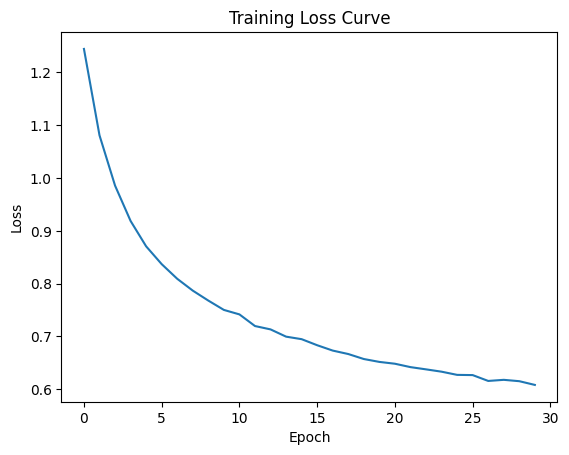

In [143]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [144]:
plt.savefig("../results/densenet_loss_data2.png")

<Figure size 640x480 with 0 Axes>

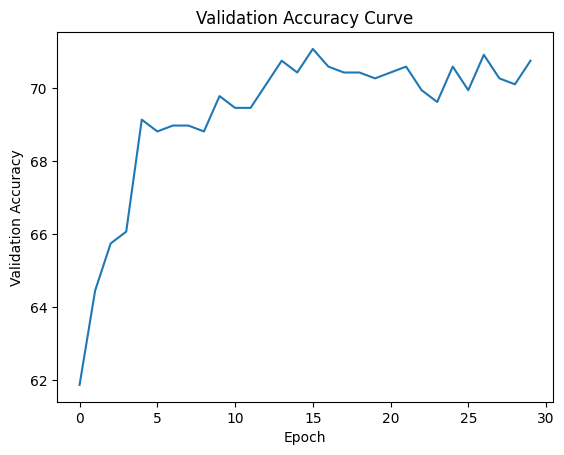

In [145]:
plt.plot(val_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title("Validation Accuracy Curve")

plt.show()

In [146]:
plt.savefig("../results/densenet_acc_data2.png")

<Figure size 640x480 with 0 Axes>